In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('../data/processed/Merged_dataset.csv')
ret_churned=pd.read_csv('Retention&Churn')

In [3]:
ret_churned1=ret_churned[['customer_id','churned']]

In [4]:
df = df.merge(
    ret_churned[['customer_id','churned']],
    on="customer_id",
    how="inner"
)

In [5]:
df["late_delivery"] = (
    pd.to_datetime(df["order_delivered_customer_date"])
    - pd.to_datetime(df["order_estimated_delivery_date"])
).dt.days

df['processing_days'] = (
    pd.to_datetime(df["order_delivered_carrier_date"], format='ISO8601')
    - pd.to_datetime(df["order_purchase_timestamp"], format='ISO8601')
).dt.days

df.head(2)

,customer_id,customer_unique_id,customer_state,customer_city,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,...,review_id,review_score,review_creation_date,product_category_name,product_weight_g,seller_city,seller_state,churned,late_delivery,processing_days
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,SP,franca,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57.000000,2017-05-25 10:35:35.000000000,...,88b8b52d46df026a9d1ad2136a59b30b,4,2017-05-26 00:00:00,moveis_escritorio,8683.0,itaquaquecetuba,SP,True,-11,6
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,SP,sao bernardo do campo,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59.000000,2018-01-29 12:41:19.000000000,...,02fc48a9efa3e3d0f1a8ea26507eeec3,5,2018-01-30 00:00:00,utilidades_domesticas,10150.0,itajai,SC,True,-8,2


In [6]:
df['late_delivery'] = df['late_delivery'] > 0

In [7]:
df['late_delivery'].value_counts()

late_delivery
False    181924
True      10723
Name: count, dtype: int64

## 1. Effect of processing delays on late delivery on

In [8]:
pro_delay=(
    df
    .groupby('late_delivery')
    .agg(
        mean_processing_days=('processing_days','mean')
    )
)
pro_delay
# Higher processing delay plays a significant role in late delivery

,mean_processing_days
late_delivery,
False,2.311306
True,5.233890


### Is processing delay is caused by a particular seller 

In [9]:
pro_delay_data=df[df['processing_days']>5]

In [10]:
late_process_count=pro_delay_data['seller_id'].value_counts().reset_index() # counting late processing deliveries by each sellers

# counting total number of orders processed by each seller
Order_count = df['seller_id'].value_counts().reset_index()
Order_count.columns = ['seller_id', 'Total_Order_Count']
Order_count

# merge 
seller_counts=pro_delay_data.merge(
    Order_count,
    on='seller_id', 
    how='inner'
)

seller_counts['late_processing_ratio']=late_process_count['count']/seller_counts['Total_Order_Count']
seller_counts['late_processing_ratio'] # The first seller is performing worse in product processing 

0        0.942911
1        0.148848
2        0.091136
3        0.211892
4        0.172432
           ...   
22402         NaN
22403         NaN
22404         NaN
22405         NaN
22406         NaN
Name: late_processing_ratio, Length: 22407, dtype: float64

### Does Delivery is late only in Certain States

In [11]:
late_ratio_state = (
    df.groupby('customer_state')['late_delivery']
      .agg(['count', 'sum'])
      .reset_index()
)

late_ratio_state.columns = ['customer_state', 'total_del_count', 'late_del_count']
late_ratio_state['late_del_ratio'] = (
    late_ratio_state['late_del_count'] / late_ratio_state['total_del_count']
)

late_ratio_state.sort_values(by='late_del_ratio', ascending=False).head() # more number of late deliveries in state AL

,customer_state,total_del_count,late_del_count,late_del_ratio
1,AL,593,117,0.197302
9,MA,1148,205,0.178571
24,SE,539,85,0.157699
19,RN,846,127,0.150118
16,PI,775,96,0.123871


### Does Delivery is late in certain Cities

In [12]:
late_ratio_city = (
    df.groupby('customer_city')['late_delivery']
      .agg(['count', 'sum'])
      .reset_index()
)

late_ratio_city.columns = ['customer_state', 'total_del_count', 'late_del_count']
late_ratio_city['late_del_ratio'] = (
    late_ratio_city['late_del_count'] / late_ratio_city['total_del_count']
)

late_ratio_city.sort_values(by='late_del_ratio', ascending=False).head()

,customer_state,total_del_count,late_del_count,late_del_ratio
1163,desembargador otoni,1,1,1.0
2416,mussurepe,1,1,1.0
2956,porto franco,1,1,1.0
126,alto sao joao,1,1,1.0
248,aramina,1,1,1.0


### Does delivery delay affect review score?

In [13]:
df.groupby('late_delivery')['review_score'].mean() 

late_delivery
False    3.973813
True     2.174671
Name: review_score, dtype: float64

In [14]:
# Looks late delivery heavily effect the customer review score

In [15]:
df.groupby('late_delivery')['review_score'].value_counts(normalize=True)

late_delivery  review_score
False          5               0.555985
               4               0.182433
               1               0.141037
               3               0.082029
               2               0.038516
True           1               0.574466
               5               0.156859
               3               0.096335
               4               0.091113
               2               0.081227
Name: proportion, dtype: float64

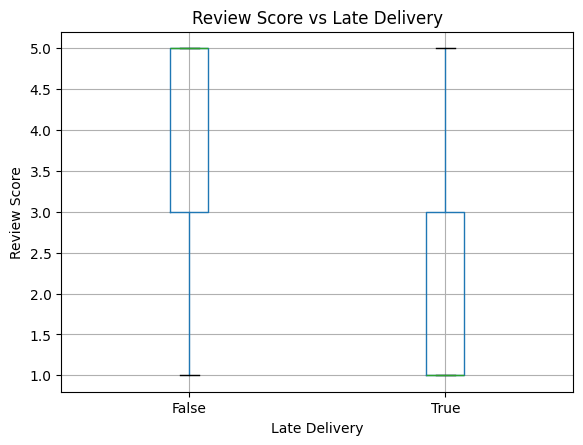

In [16]:
df.boxplot(column='review_score', by='late_delivery')
plt.title('Review Score vs Late Delivery')
plt.suptitle('')
plt.xlabel('Late Delivery')
plt.ylabel('Review Score')
plt.show()

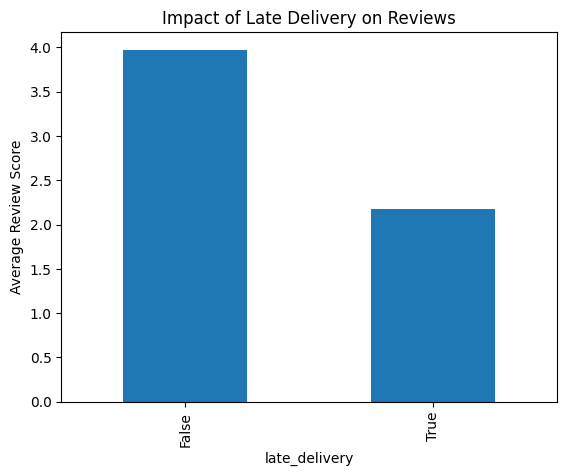

In [17]:
df.groupby('late_delivery')['review_score'].mean().plot(kind='bar')
plt.ylabel('Average Review Score')
plt.title('Impact of Late Delivery on Reviews')
plt.show()

## stastical significance of Result

In [18]:
late = df[df['late_delivery'] == True]['review_score']
on_time = df[df['late_delivery'] == False]['review_score']

ttest_ind(late, on_time, equal_var=False)

# Delivery delay significantly affects review score as p value is less than 0.05

TtestResult(statistic=np.float64(-116.94020651902296), pvalue=np.float64(0.0), df=np.float64(11825.109008322794))